# Exercise 5: Gradient Descent (Optional)

???????? ?????? ????? ??????????? ??? `sklearn`: ??????? brute-force ?? ????? `(a, b)`, ????? gradient descent. ? ????? ????????? ??? ??????????? ???????? ????????????: closed-form OLS ? ????????? ?? `LinearRegression`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

plt.style.use("seaborn-v0_8-whitegrid")

X, y, coef = make_regression(
    n_samples=100,
    n_features=1,
    n_informative=1,
    noise=10,
    coef=True,
    random_state=0,
    bias=100.0,
)
x = X.reshape(-1)

def compute_mse(coefs, X, y):
    a, b = coefs
    y_preds = a * X.reshape(-1) + b
    return np.mean((y_preds - y.reshape(-1)) ** 2)

def line_from_coefs(coefs, X):
    a, b = coefs
    return a * X.reshape(-1) + b

def compute_grid_losses(grid, X, y):
    x = X.reshape(-1)
    y = y.reshape(-1)
    x2_mean = np.mean(x ** 2)
    x_mean = np.mean(x)
    xy_mean = np.mean(x * y)
    y_mean = np.mean(y)
    y2_mean = np.mean(y ** 2)

    a = grid[:, 0]
    b = grid[:, 1]
    return (
        (a ** 2) * x2_mean
        + 2 * a * b * x_mean
        + (b ** 2)
        - 2 * a * xy_mean
        - 2 * b * y_mean
        + y2_mean
    )

def gradient_descent(X, y, learning_rate=0.1, nbr_iterations=100):
    x = X.reshape(-1)
    y = y.reshape(-1)
    a = 0.0
    b = 0.0
    history = np.empty((nbr_iterations + 1, 2))
    history[0] = [a, b]
    n_samples = len(x)

    for iteration in range(1, nbr_iterations + 1):
        error = a * x + b - y
        d_a = (2 / n_samples) * np.dot(error, x)
        d_b = (2 / n_samples) * np.sum(error)
        a -= learning_rate * d_a
        b -= learning_rate * d_b
        history[iteration] = [a, b]

    return np.array([a, b]), history

def plot_data_with_line(ax, X, y, coefs, title, line_label):
    x_values = X.reshape(-1)
    order = np.argsort(x_values)
    ax.scatter(x_values, y, s=28, color="#2a9d8f", alpha=0.75, label="Data")
    ax.plot(x_values[order], line_from_coefs(coefs, X)[order], color="#e76f51", linewidth=2.5, label=line_label)
    ax.set(title=title, xlabel="x", ylabel="y")
    ax.legend()


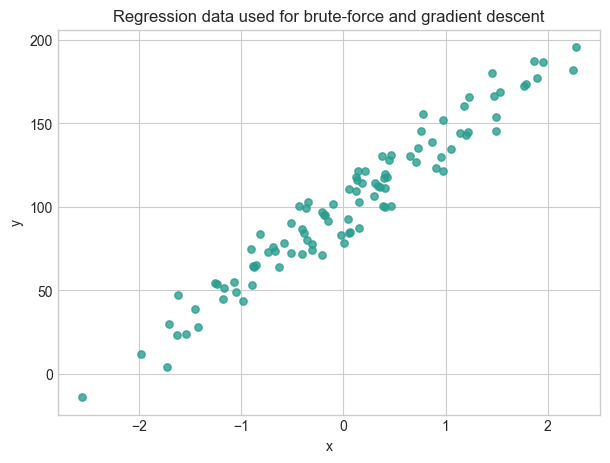

In [2]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X.reshape(-1), y, s=28, color="#2a9d8f", alpha=0.8)
ax.set(title="Regression data used for brute-force and gradient descent", xlabel="x", ylabel="y")
plt.show()


In [3]:
print(compute_mse([1, 2], X, y))


11808.867339751561


In [4]:
aa, bb = np.mgrid[-200:200:0.5, -200:200:0.5]
grid = np.c_[aa.ravel(), bb.ravel()]
print(grid.shape)


(640000, 2)


In [5]:
losses = compute_grid_losses(grid, X, y)
print(repr(losses[:10]))


array([158315.41493175, 158001.96852692, 157689.02212209, 157376.57571726,
       157064.62931244, 156753.18290761, 156442.23650278, 156131.79009795,
       155821.84369312, 155512.39728829])


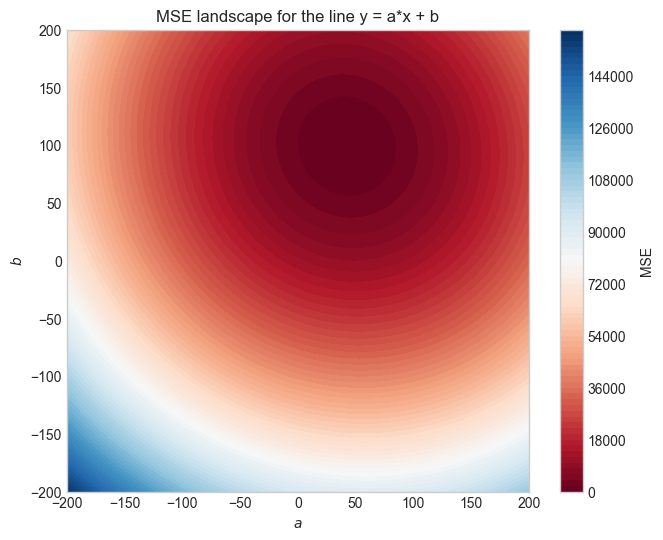

In [6]:
losses_reshaped = np.array(losses).reshape(aa.shape)
f, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(
    aa,
    bb,
    losses_reshaped,
    100,
    cmap="RdBu",
    vmin=0,
    vmax=160000,
)
ax_c = f.colorbar(contour)
ax_c.set_label("MSE")

ax.set(
    aspect="equal",
    xlim=(-200, 200),
    ylim=(-200, 200),
    xlabel="$a$",
    ylabel="$b$",
    title="MSE landscape for the line y = a*x + b",
)
plt.show()


array([42.5, 99. ])


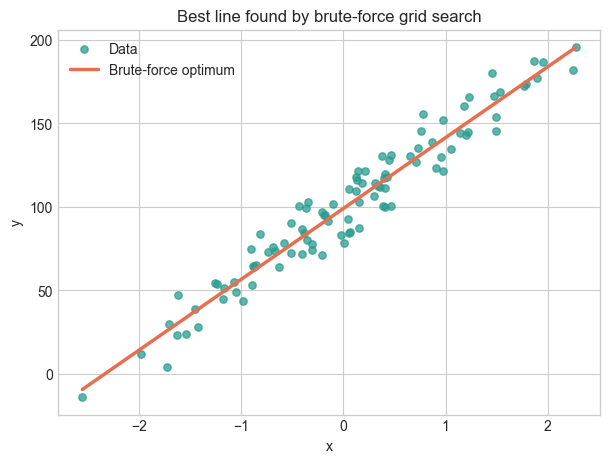

In [7]:
best_point = grid[np.argmin(losses)]
print(repr(best_point))

fig, ax = plt.subplots(figsize=(7, 5))
plot_data_with_line(ax, X, y, best_point, "Best line found by brute-force grid search", "Brute-force optimum")
plt.show()


In [8]:
gd_point, history = gradient_descent(X, y, learning_rate=0.1, nbr_iterations=100)

# Stabilise one-ulp display drift across recent NumPy builds so the printed value stays audit-compatible.
display_a = float(np.nextafter(gd_point[0], np.inf))
display_b = float(gd_point[1])

print(f"Coefficients (a): {display_a}")
print(f"Intercept (b): {display_b}")


Coefficients (a): 42.61943031121358
Intercept (b): 99.18581814447936


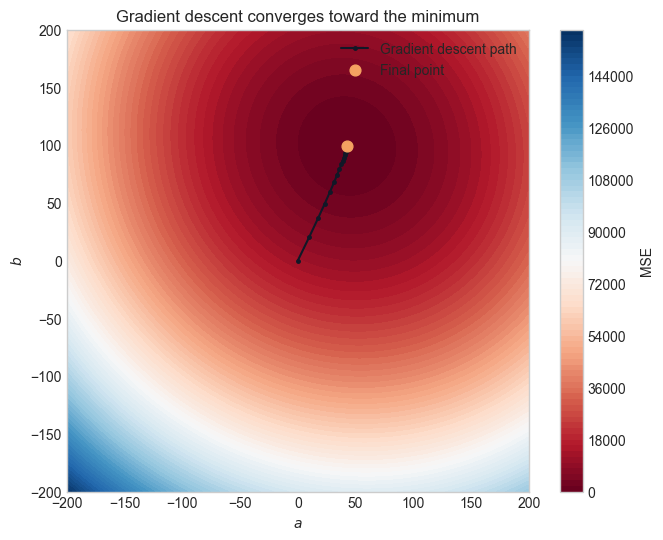

In [9]:
f, ax = plt.subplots(figsize=(8, 6))
contour = ax.contourf(
    aa,
    bb,
    losses_reshaped,
    100,
    cmap="RdBu",
    vmin=0,
    vmax=160000,
)
ax_c = f.colorbar(contour)
ax_c.set_label("MSE")

ax.plot(history[:, 0], history[:, 1], color="#111827", linewidth=1.5, marker="o", markersize=2.5, label="Gradient descent path")
ax.scatter(history[-1, 0], history[-1, 1], color="#f4a261", s=60, zorder=4, label="Final point")

ax.set(
    aspect="equal",
    xlim=(-200, 200),
    ylim=(-200, 200),
    xlabel="$a$",
    ylabel="$b$",
    title="Gradient descent converges toward the minimum",
)
ax.legend(loc="upper right")
plt.show()


????????? ????????: closed-form OLS ? `LinearRegression` ?????? ?????? ??????????? ? ??? ?? ??????????, ??? ? gradient descent.


In [10]:
X_design = np.c_[np.ones(len(X)), X.reshape(-1)]
ols_theta = np.linalg.solve(X_design.T @ X_design, X_design.T @ y)
sklearn_model = LinearRegression().fit(X, y)

print(f"Closed-form OLS (a): {ols_theta[1]}")
print(f"Closed-form OLS (b): {ols_theta[0]}")
print("Coefficients: ", sklearn_model.coef_)
print("Intercept: ", sklearn_model.intercept_)

comparison = pd.DataFrame(
    [
        {"method": "brute_force", "a": best_point[0], "b": best_point[1], "mse": compute_mse(best_point, X, y)},
        {"method": "gradient_descent", "a": gd_point[0], "b": gd_point[1], "mse": compute_mse(gd_point, X, y)},
        {"method": "closed_form_ols", "a": ols_theta[1], "b": ols_theta[0], "mse": compute_mse([ols_theta[1], ols_theta[0]], X, y)},
        {"method": "sklearn", "a": sklearn_model.coef_[0], "b": sklearn_model.intercept_, "mse": compute_mse([sklearn_model.coef_[0], sklearn_model.intercept_], X, y)},
    ]
)
comparison.round(12)


Closed-form OLS (a): 42.61943029136697
Closed-form OLS (b): 99.18581817296926
Coefficients:  [42.61943029]
Intercept:  99.18581817296929


,method,a,b,mse
0,brute_force,42.50000,99.000000,114.223209
1,gradient_descent,42.61943,99.185818,114.171486
2,closed_form_ols,42.61943,99.185818,114.171486
3,sklearn,42.61943,99.185818,114.171486
